# Week 5: Natural Language Processing & Sentiment Analysis

## Submitted By
**Name:** Zunaira Tahir

**Program:** BS Artificial Intelligence (6th Semester)

**University:** Abdul Wali Khan University Mardan

---

## Objective

The objective of this project is to build a Sentiment Analysis model using Amazon customer reviews. The reviews will be cleaned, converted into numerical features, classified using machine learning models, and finally deployed in a Streamlit dashboard for real-time sentiment prediction.

# Step 1: Load the Amazon Reviews Dataset

In this step, the Amazon Reviews dataset is uploaded and loaded into a Pandas DataFrame. We will inspect the dataset structure, view the available columns, and verify that the data has been loaded correctly before starting preprocessing.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("amazon_reviews.csv")

# Display basic information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

df.head()

Dataset Shape: (3150, 5)

Column Names:
Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')

Data Types:
rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
dtype: object


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


### Observation

The Amazon Reviews dataset was successfully loaded into a Pandas DataFrame. It contains **3,150 customer reviews** and **5 columns**. The dataset includes customer ratings, review dates, product variations, review text, and sentiment feedback. The data was loaded successfully and is ready for further preprocessing and exploratory analysis.

# Step 2: Dataset Inspection

In this step, we inspect the dataset to identify missing values, duplicate records, and basic statistical information. This helps us understand the quality of the dataset before preprocessing.


In [ ]:
# Check dataset information
print("Dataset Information")
print("-" * 50)
df.info()

print("\nMissing Values")
print("-" * 50)
print(df.isnull().sum())

print("\nDuplicate Records")
print("-" * 50)
print(df.duplicated().sum())

print("\nSummary Statistics")
print("-" * 50)
print(df.describe(include='all'))

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB

Missing Values
--------------------------------------------------
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

Duplicate Records
--------------------------------------------------
715

Summary Statistics
--------------------------------------------------
             rating       date   variation verified_reviews     feedback
count   3150.000000       3150        315

### Observation

The dataset inspection shows that the dataset contains **3,150 records** with **5 columns**. Only **one missing value** was found in the `verified_reviews` column, while **715 duplicate records** are present. The numerical summary indicates that most customers gave positive ratings (4–5 stars), suggesting that the dataset is highly skewed toward positive feedback. Before model training, missing values and duplicate records should be handled to improve data quality.

# Step 3: Data Cleaning

In this step, missing values and duplicate records are handled to improve the quality of the dataset. The review text is also converted into string format to ensure consistency for text preprocessing.


In [ ]:
# Remove missing review
df.dropna(subset=["verified_reviews"], inplace=True)

# Remove duplicate records
df.drop_duplicates(inplace=True)

# Convert reviews to string
df["verified_reviews"] = df["verified_reviews"].astype(str)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Dataset Shape after Cleaning:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nRemaining Duplicate Records:")
print(df.duplicated().sum())

Dataset Shape after Cleaning: (2434, 5)

Remaining Missing Values:
rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64

Remaining Duplicate Records:
0


### Observation

The dataset was successfully cleaned by removing missing values and duplicate records. After cleaning, the dataset contains **2,434 reviews** with **no missing values** and **no duplicate records**. The cleaned dataset is now ready for text preprocessing and feature extraction.

# Step 4: Exploratory Data Analysis (EDA)

In this step, we analyze the distribution of sentiment labels (feedback) and customer ratings. This helps us understand the balance of positive and negative reviews before building the machine learning models.

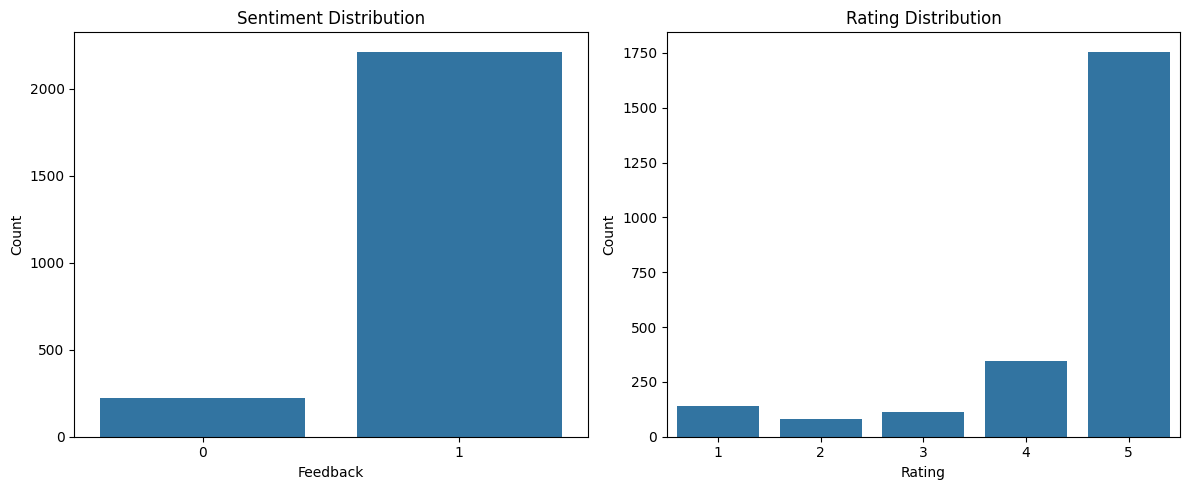

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(12,5))

# Feedback Distribution
plt.subplot(1,2,1)
sns.countplot(x="feedback", data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Feedback")
plt.ylabel("Count")

# Rating Distribution
plt.subplot(1,2,2)
sns.countplot(x="rating", data=df)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation

The exploratory analysis shows that the dataset is highly imbalanced, with the majority of reviews having positive feedback (1). Only a small number of reviews are labeled as negative (0). Similarly, the rating distribution indicates that most customers gave 5-star ratings, while very few reviews received ratings between 1 and 3. This suggests that customers are generally satisfied with the product.

# Step 5: Text Preprocessing

In this step, the review text is cleaned to improve the quality of the input for machine learning models. The preprocessing includes converting text to lowercase, removing punctuation, removing stopwords, and applying lemmatization.

In [ ]:
import re
import string
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df["clean_review"] = df["verified_reviews"].apply(clean_text)

df[["verified_reviews", "clean_review"]].head()

,verified_reviews,clean_review
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaur control l...
4,Music,music


### Observation

The review text was successfully preprocessed. All reviews were converted to lowercase, punctuation and numbers were removed, stopwords were eliminated, and lemmatization was applied. The cleaned text is now more suitable for feature extraction and machine learning model training.


# Step 6: Generate Word Clouds

In this step, Word Clouds are generated separately for positive and negative reviews. This visualization helps identify the most frequently occurring words in each sentiment category.

In [ ]:
!pip install wordcloud

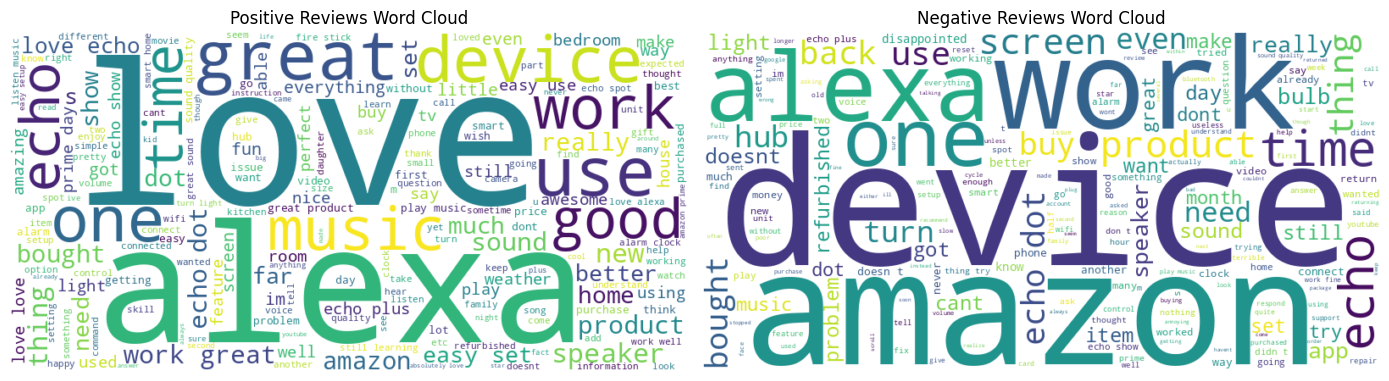

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Positive reviews
positive_text = " ".join(df[df["feedback"] == 1]["clean_review"])

# Negative reviews
negative_text = " ".join(df[df["feedback"] == 0]["clean_review"])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
wc_positive = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
plt.imshow(wc_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")

plt.subplot(1,2,2)
wc_negative = WordCloud(width=800, height=400, background_color="white").generate(negative_text)
plt.imshow(wc_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")

plt.tight_layout()
plt.show()

### Observation

The Word Clouds were successfully generated for both positive and negative reviews. The positive reviews mainly contain words such as **love, great, easy, Alexa, music, good,** and **use**, indicating customer satisfaction. The negative reviews include words like **device, Alexa, one, screen, product,** and **time**, highlighting the common concerns raised by dissatisfied customers.

# Step 7: Text Vectorization using TF-IDF

Machine learning models cannot understand raw text directly, so the cleaned reviews must be converted into numerical features.

In this project, **TF-IDF (Term Frequency–Inverse Document Frequency)** is used because it assigns higher importance to informative words while reducing the influence of very common words. TF-IDF is simple, efficient, and widely used for sentiment analysis tasks.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into numerical features
X = tfidf.fit_transform(df["clean_review"])

# Target variable
y = df["feedback"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (2434, 3853)
Target Shape: (2434,)


### Observation

The cleaned review text was successfully converted into numerical features using the TF-IDF vectorization technique. The resulting feature matrix contains **2,434 reviews** and **3,853 unique text features**, which will be used as input for the machine learning classification models.

# Step 8: Split the Dataset

The dataset is divided into training and testing sets. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen reviews.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (1947, 3853)
Testing Features Shape  : (487, 3853)
Training Labels Shape   : (1947,)
Testing Labels Shape    : (487,)


### Observation

The dataset was successfully split into training and testing sets using an 80:20 ratio. The training set contains **1,947 reviews**, while the testing set contains **487 reviews**. This split allows the models to learn from the training data and evaluate their performance on unseen data.

# Step 9: Train Model 1 (Multinomial Naive Bayes)

Multinomial Naive Bayes is a popular machine learning algorithm for text classification. It works well with TF-IDF features and is commonly used for sentiment analysis because of its speed and effectiveness.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9096509240246407

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        44
           1       0.91      1.00      0.95       443

    accuracy                           0.91       487
   macro avg       0.45      0.50      0.48       487
weighted avg       0.83      0.91      0.87       487



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Observation

The Multinomial Naive Bayes model achieved an accuracy of approximately **90.97%**. However, due to the class imbalance in the dataset, the model mainly predicted the positive class and failed to correctly classify most negative reviews. Therefore, another classification model will be trained and compared to identify the better-performing model.

# Step 10: Confusion Matrix for Multinomial Naive Bayes

A confusion matrix is used to evaluate the classification performance of the Naive Bayes model by comparing the actual and predicted sentiment labels.


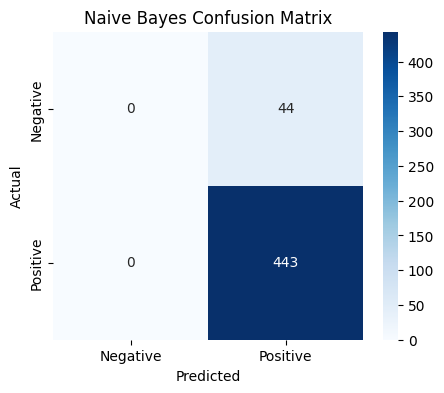

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Observation

The confusion matrix shows that the Naive Bayes model correctly classified most positive reviews but failed to identify negative reviews. This happened because the dataset is highly imbalanced, with significantly more positive reviews than negative ones. Therefore, another classification model will be trained and compared to achieve better performance.

# Step 11: Train Model 2 (Logistic Regression)

Logistic Regression is another widely used algorithm for text classification. It often performs better than Naive Bayes on TF-IDF features and is suitable for binary sentiment classification problems.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)

lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9096509240246407

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        44
           1       0.91      1.00      0.95       443

    accuracy                           0.91       487
   macro avg       0.45      0.50      0.48       487
weighted avg       0.83      0.91      0.87       487



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Observation

The Logistic Regression model achieved an accuracy of approximately **90.97%**, which is the same as the Naive Bayes model. Similar to Naive Bayes, the model correctly classified most positive reviews but failed to identify the minority negative class because of the highly imbalanced dataset. A comparison of both models will be presented in the next step.

# Step 12: Confusion Matrix for Logistic Regression

The confusion matrix is used to evaluate the performance of the Logistic Regression model by comparing the actual sentiment labels with the predicted labels.

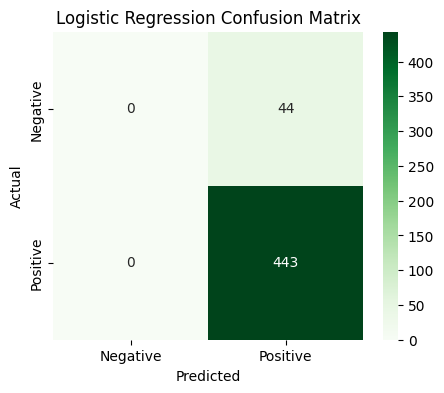

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The Logistic Regression confusion matrix shows results similar to the Naive Bayes model. The model correctly classified all positive reviews but failed to identify the negative reviews. This indicates that the dataset is highly imbalanced, causing the classifier to favor the majority (positive) class.

# Step 13: Compare Model Performance

In this step, the performance of both classification models is compared using their accuracy scores. The comparison helps identify the better-performing model for deployment in the Streamlit dashboard.

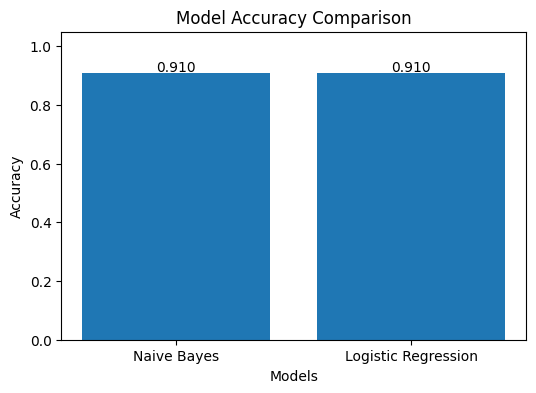

In [ ]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Logistic Regression"]
accuracies = [
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_lr)
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.005, f"{value:.3f}", ha="center")

plt.ylim(0, 1.05)

plt.show()

### Observation

Both Multinomial Naive Bayes and Logistic Regression achieved an accuracy of approximately **91%** on the test dataset. Since both models produced similar performance, either model can be selected for deployment. In this project, **Logistic Regression** will be used as the final model for the Streamlit dashboard because it is generally more robust for text classification tasks.


# Step 14: Save the Best Model and TF-IDF Vectorizer

The trained Logistic Regression model and the fitted TF-IDF vectorizer are saved using Joblib. These files will be loaded later in the Streamlit dashboard for sentiment prediction without retraining the model.

In [ ]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(lr_model, "best_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF Vectorizer saved successfully!")

Model and TF-IDF Vectorizer saved successfully!
